In [5]:
import sys
print(sys.version)

3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.metrics import adjusted_rand_score

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from sklearn.metrics import confusion_matrix

import statsmodels.api as sm

from scipy.stats import f

from tigramite import data_processing as pp
from tigramite.pcmci import PCMCI
from tigramite.independence_tests.parcorr import ParCorr

In [7]:
# from google.colab import drive
# drive.mount('/content/drive')

In [8]:
# file_path = '/content/drive/MyDrive/Thesis/regime_dataset_big.csv'

In [9]:
df = pd.read_csv('regime_dataset_big.csv')

In [10]:
df.head()

,L_x,Gamma,T_in,H_r,F_r,true_regime,t
0,37.500000,1.600000,0.300000,0.750000,28.000000,0,0
1,37.530472,1.496002,0.375045,0.844056,39.289804,0,1
2,37.397207,1.519185,0.335916,0.832971,44.948698,0,2
3,37.495426,1.605046,0.338928,0.937398,47.911425,0,3
4,37.409954,1.641417,0.239147,1.006503,49.242661,0,4


In [11]:
df.tail()

,L_x,Gamma,T_in,H_r,F_r,true_regime,t
9995,37.781136,1.762538,0.194675,0.417434,14.245049,1,9995
9996,37.715843,1.594590,0.167139,0.553451,13.906031,1,9996
9997,37.834564,1.652536,0.156983,0.601871,14.127062,1,9997
9998,37.804448,1.742148,0.256367,0.634200,14.003143,1,9998
9999,37.764227,1.523800,0.305301,0.603810,13.920244,1,9999


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   L_x          10000 non-null  float64
 1   Gamma        10000 non-null  float64
 2   T_in         10000 non-null  float64
 3   H_r          10000 non-null  float64
 4   F_r          10000 non-null  float64
 5   true_regime  10000 non-null  int64  
 6   t            10000 non-null  int64  
dtypes: float64(5), int64(2)
memory usage: 547.0 KB


In [13]:
df.describe()

,L_x,Gamma,T_in,H_r,F_r,true_regime,t
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,37.484366,1.601639,0.311129,0.749425,32.385290,0.500000,4999.50000
std,0.231291,0.226443,0.218796,0.234377,18.526419,0.500025,2886.89568
min,36.620153,0.737944,-0.475262,-0.174167,13.024090,0.000000,0.00000
25%,37.331058,1.445922,0.162009,0.593711,13.855524,0.000000,2499.75000
50%,37.488085,1.598987,0.316198,0.754149,28.000000,0.500000,4999.50000
75%,37.638872,1.758270,0.459085,0.905640,50.913599,1.000000,7499.25000
max,38.321363,2.401741,1.037232,1.478487,52.592813,1.000000,9999.00000


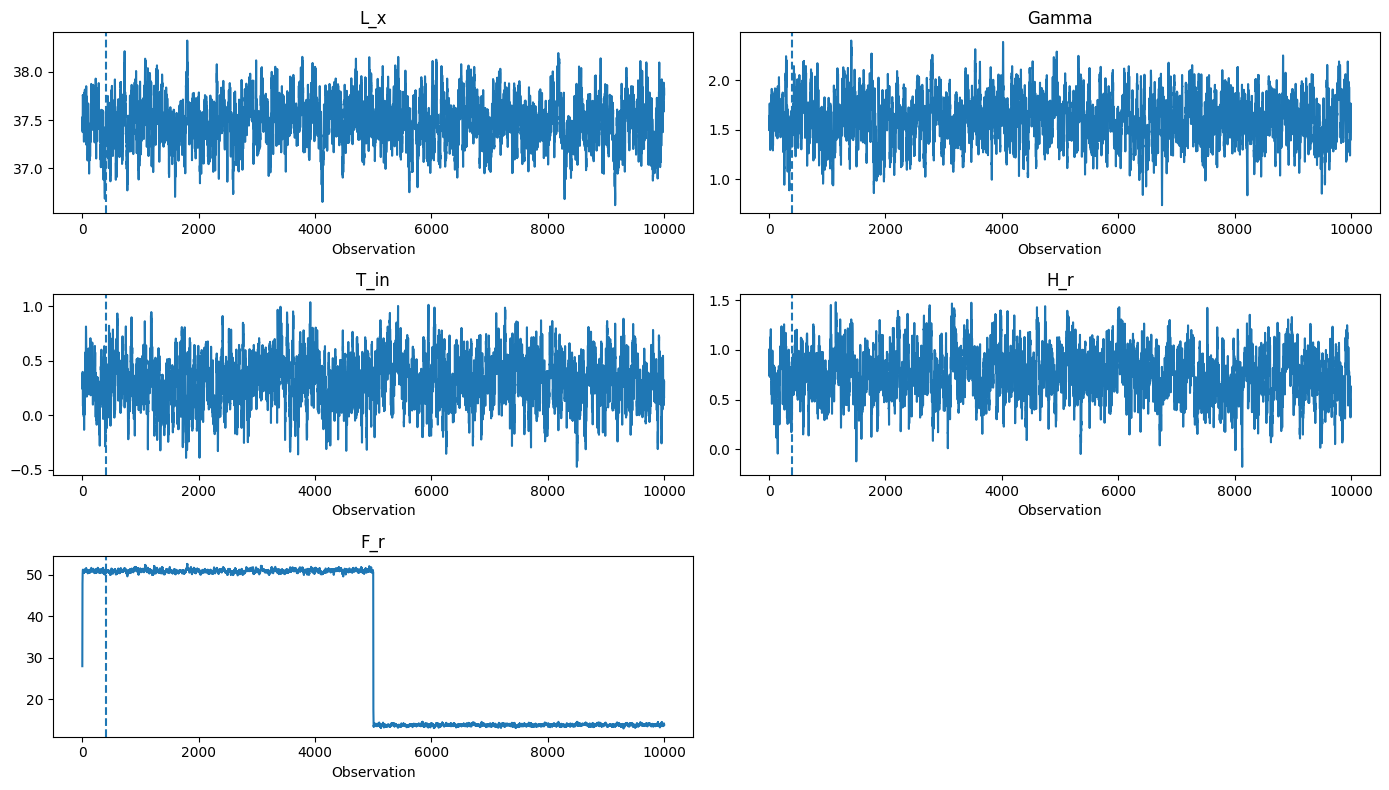

In [14]:
features = ["L_x", "Gamma", "T_in", "H_r", "F_r"]

plt.figure(figsize=(14,8))

for i, col in enumerate(features):
    plt.subplot(3,2,i+1)
    plt.plot(df["t"], df[col])
    plt.axvline(400, linestyle="--")
    plt.title(col)
    plt.xlabel("Observation")

plt.tight_layout()
plt.show()

all features have spike at 5000th observation

In [15]:
X = df[features]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(10000, 5)


testing a K-means


In [16]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=20
)

predicted_regime = kmeans.fit_predict(X_scaled)
df["predicted_regime"] = predicted_regime

In [17]:
predicted_regime

array([1, 0, 0, ..., 1, 1, 1])

In [18]:
len(predicted_regime)

10000

In [19]:
true = df["true_regime"]
pred = df["predicted_regime"]

ari = adjusted_rand_score(
    true,
    pred
)

print("Adjusted Rand Index:", ari)

Adjusted Rand Index: 0.9995999999960008


ARI is negative so poor recovery

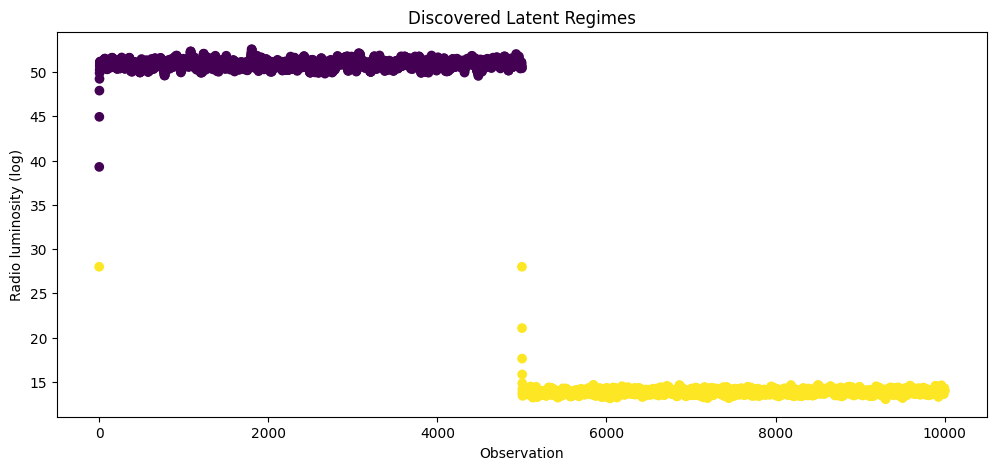

In [20]:
plt.figure(figsize=(12,5))

plt.scatter(
    df["t"],
    df["F_r"],
    c=df["predicted_regime"]
)

plt.xlabel("Observation")
plt.ylabel("Radio luminosity (log)")
plt.title("Discovered Latent Regimes")

plt.show()

Yellow cluster → high F_r values (mostly the initial transient points)
Purple cluster → the long decay + stable region
It is not discovering Hard State vs Soft State. It is discovering the magnitude difference caused by initialization/AR decay.

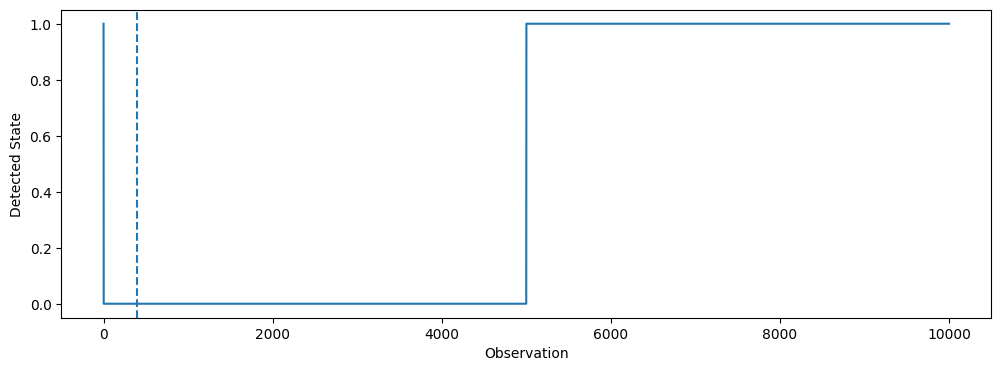

In [21]:
plt.figure(figsize=(12,4))

plt.plot(
    df["t"],
    df["predicted_regime"]
)

plt.axvline(
    400,
    linestyle="--"
)

plt.xlabel("Observation")
plt.ylabel("Detected State")

plt.show()

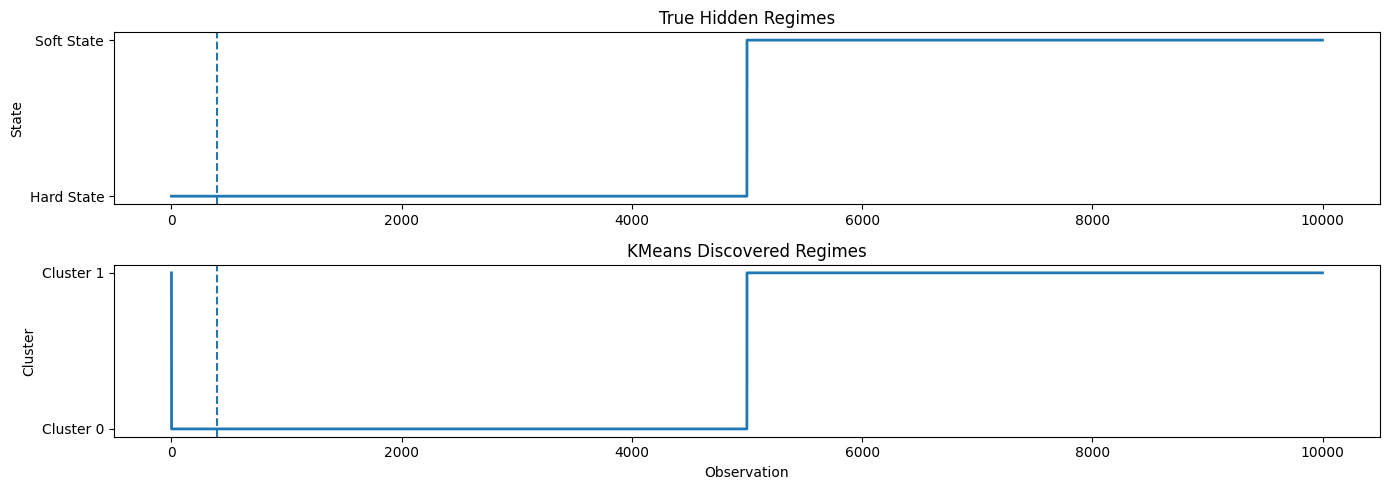

In [22]:
plt.figure(figsize=(14,5))

# True regimes
plt.subplot(2,1,1)

plt.plot(
    df["t"],
    df["true_regime"],
    linewidth=2
)

plt.title("True Hidden Regimes")
plt.ylabel("State")

plt.yticks(
    [0,1],
    ["Hard State","Soft State"]
)

plt.axvline(
    400,
    linestyle="--"
)


# KMeans detected regimes
plt.subplot(2,1,2)

plt.plot(
    df["t"],
    df["predicted_regime"],
    linewidth=2
)

plt.title("KMeans Discovered Regimes")
plt.xlabel("Observation")
plt.ylabel("Cluster")

plt.yticks(
    [0,1],
    ["Cluster 0","Cluster 1"]
)

plt.axvline(
    400,
    linestyle="--"
)

plt.tight_layout()

plt.show()

In [23]:
changes = df[
    df["predicted_regime"].diff()!=0
]

print(changes[["t","predicted_regime"]])

         t  predicted_regime
0        0                 1
1        1                 0
5000  5000                 1


In [24]:
print(
    confusion_matrix(
        df["true_regime"],
        df["predicted_regime"]
    )
)

print("\nFlipped:")
print(confusion_matrix(
    df["true_regime"],
    1 - df["predicted_regime"]
))

[[4999    1]
 [   0 5000]]

Flipped:
[[   1 4999]
 [5000    0]]


                 KMeans
              0        1

    Hard 0     387      13

    Soft 1     391       9

KMeans did not discover the two accretion states. It discovered something else (mostly the initial transient behavior).

387/400=96.75% -> hard state accuracy.

9/400=2.25% -> soft state accuracy

KMeans basically learned:

Most observations belong to one big cluster, and a small group of high luminosity points belong to another.

It did not learn that there are two temporal accretion states. This confirms what the plot shows.

In [25]:
from sklearn.metrics import adjusted_rand_score

ari = adjusted_rand_score(
    df["true_regime"],
    df["predicted_regime"]
)

print("ARI:", ari)

ARI: 0.9995999999960008


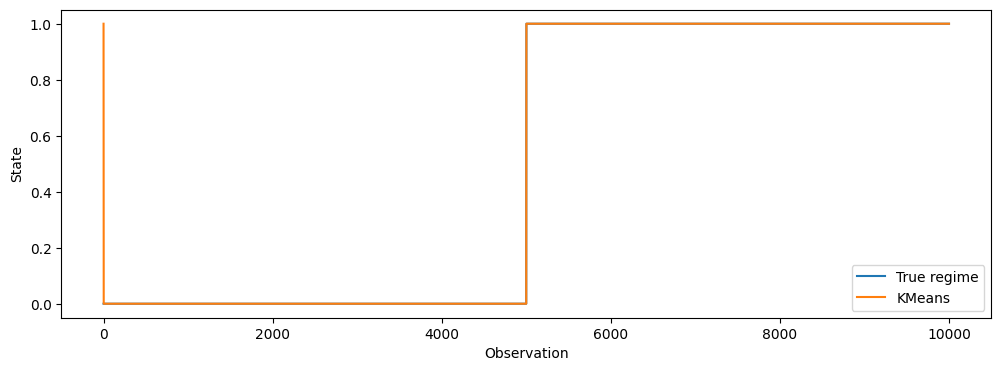

In [26]:


plt.figure(figsize=(12,4))

plt.plot(
    df["t"],
    df["true_regime"],
    label="True regime"
)

plt.plot(
    df["t"],
    df["predicted_regime"],
    label="KMeans"
)

plt.legend()
plt.xlabel("Observation")
plt.ylabel("State")

plt.show()

TEST

In [27]:
df["F_r_lag1"] = df["F_r"].shift(1)

df = df.dropna()

features = [
    "L_x",
    "Gamma",
    "T_in",
    "H_r",
    "F_r_lag1"
]

target = "F_r"


In [28]:
df.tail()

,L_x,Gamma,T_in,H_r,F_r,true_regime,t,predicted_regime,F_r_lag1
9995,37.781136,1.762538,0.194675,0.417434,14.245049,1,9995,1,14.263511
9996,37.715843,1.594590,0.167139,0.553451,13.906031,1,9996,1,14.245049
9997,37.834564,1.652536,0.156983,0.601871,14.127062,1,9997,1,13.906031
9998,37.804448,1.742148,0.256367,0.634200,14.003143,1,9998,1,14.127062
9999,37.764227,1.523800,0.305301,0.603810,13.920244,1,9999,1,14.003143


In [29]:
X = df[features]
y = df[target]

X_const = sm.add_constant(X)

global_model = sm.OLS(y, X_const).fit()

print(global_model.summary())

                            OLS Regression Results                            
Dep. Variable:                    F_r   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 7.352e+06
Date:                Fri, 28 Aug 2026   Prob (F-statistic):               0.00
Time:                        12:20:54   Log-Likelihood:                -2328.5
No. Observations:                9999   AIC:                             4669.
Df Residuals:                    9993   BIC:                             4712.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.8648      0.496     -5.781      0.0

In [30]:
RSS_global = np.sum(
    global_model.resid**2
)

print("Global RSS:", RSS_global)

Global RSS: 932.7162031279921


In [31]:
features = [
    "L_x",
    "Gamma",
    "T_in",
    "H_r",
    "F_r_lag1"
]

target = "F_r"

X = df[features].values
y = df[target].values

true_regime = df["true_regime"].values

time = df["t"].values

ols


In [32]:
def fit_ols(X, y):
  X_const = sm.add_constant(X)

  model = sm.OLS(
      y,
      X_const
  ).fit()

  beta = model.params

  rss = model.ssr

  return model, beta, rss

global ols

In [33]:
global_model, beta_global, rss_global = fit_ols(
    X,
    y
)

print(global_model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 7.352e+06
Date:                Fri, 28 Aug 2026   Prob (F-statistic):               0.00
Time:                        12:20:54   Log-Likelihood:                -2328.5
No. Observations:                9999   AIC:                             4669.
Df Residuals:                    9993   BIC:                             4712.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.8648      0.496     -5.781      0.0

In [34]:
print("Global RSS:", rss_global)

Global RSS: 932.7162031279906


chow test

In [35]:
def chow_test(X, y, split):
  X1 = X[:split]
  X2 = X[split:]

  y1 = y[:split]
  y2 = y[split:]

  n = len(y)
  k = X.shape[1]+1

  _, _, rss_full = fit_ols(X, y)
  _, _, rss1 = fit_ols(X1, y1)
  _, _, rss2 = fit_ols(X2, y2)

  numerator = (rss_full - rss1 - rss2) / k

  denominator = (rss1 + rss2) / (n - 2 * k)

  F = numerator / denominator

  p = 1-stats.f.cdf(
        F,
        k,
        n-2*k
    )

  return F, p

In [36]:
def search_breakpoint(X, y, min_size=50):
  best_F = -np.inf
  best_split = None
  best_p = None

  for split in range(
      min_size,
      len(y) - min_size
  ):
    F, p = chow_test(X, y, split)

    if F > best_F:
      best_F = F
      best_split = split
      best_p = p

  return best_split, best_F, best_p

In [37]:
split,F,p = search_breakpoint(X,y)


print("Best transition:")
print("t =",split)
print("F =",F)
print("p =",p)

Best transition:
t = 4999
F = 13127.873019776225
p = 1.1102230246251565e-16


BIC validation

In [38]:
def bic_score(X, y):
  n = len(y)

  P = X.shape[1] + 1

  _, _, rss = fit_ols(X, y)

  return (
      n * np.log(rss/n + 1e-10)
      +
      P * np.log(n)
  )

In [39]:
def bic_split_accept(X, y, split):
  parent = bic_score(X, y)

  left = bic_score(
      X[:split],
      y[:split]
  )

  right = bic_score(
      X[split:],
      y[split:]
  )

  child = left + right + 5 * np.log(len(y))

  accepted = child < parent

  return accepted, parent, child


In [40]:
accepted,parent,child = bic_split_accept(
    X,
    y,
    split
)


print("BIC accepted:",accepted)

print(parent,child)

BIC accepted: True
-23663.76029880298 -45429.50684946547


In [41]:
class TemporalLIRANode:

    def __init__(
        self,
        indices,
        depth=0
    ):

        self.indices = indices # observation indices in this node

        self.depth = depth

        self.left = None
        self.right = None

        self.is_leaf = True

        self.split_point = None # time index of split

        self.beta = None # ols coefficient for this split
        self.rss = None # rss for this leaf

        self.regime_id = None

In [42]:
class TemporalLIRA:
    def __init__(
        self,
        min_size=50,
        max_depth=5
    ):

        self.min_size = min_size
        self.max_depth = max_depth

        self.root = None

        self.leaves = []
        self.X         = None
        self.y         = None

    def fit(self,X,y):
        self.X = X
        self.y = y

        _, beta_g, rss_g = fit_ols(X, y)

        indices=np.arange(len(y))


        self.root = TemporalLIRANode(
            indices,
            depth=0
        )


        self._split_node(
            self.root
        )


        self.leaves=[]

        self._collect_leaves(
            self.root
        )


        for i,leaf in enumerate(self.leaves):

            leaf.regime_id=i


        return self

    def _split_node(self,node):
      idx=node.indices

      X_node=self.X[idx]
      y_node=self.y[idx]


      n=len(idx)

      if n < 2*self.min_size:

          self.make_leaf(node)

          return

      if node.depth >= self.max_depth:

          self.make_leaf(node)

          return

      split,F,p = search_breakpoint(
          X_node,
          y_node,
          self.min_size
      )


      if split is None:

          self.make_leaf(node)

          return


      left_idx = idx[:split]

      right_idx = idx[split:]

      # Map local split index back to global time
      global_split_time = idx[split]


      accepted,_,_=bic_split_accept(
          X_node,
          y_node,
          split
      )


      if (not accepted) or (p > 0.01) or F < 100:

          self.make_leaf(node)

          return



      print(
          "SPLIT:",
          "depth=",node.depth,
          "time=",left_idx[-1],
          "F=",round(F,3)
      )


      node.is_leaf = False

      node.split_point = global_split_time



      node.left = TemporalLIRANode(
          left_idx,
          node.depth+1
      )


      node.right = TemporalLIRANode(
          right_idx,
          node.depth+1
      )

      self._split_node(
          node.left
      )


      self._split_node(
          node.right
      )
    def make_leaf(self,node):
      X_leaf=self.X[node.indices]

      y_leaf=self.y[node.indices]


      _, beta, rss=fit_ols(
          X_leaf,
          y_leaf
      )


      node.beta=beta
      node.rss=rss

      node.is_leaf=True


    def _collect_leaves(self,node):
      if node is None:
        return

      if node.is_leaf:
          self.leaves.append(node)
          return

      self._collect_leaves(
          node.left
      )

      self._collect_leaves(
          node.right
      )

    def predict_regime(self):
      labels=np.zeros(
          len(self.y),
          dtype=int
      )


      for leaf in self.leaves:
        labels[leaf.indices]=leaf.regime_id

      return labels

    def get_regime_data(self, k):
      leaf = self.leaves[k]
      return self.X[leaf.indices], self.y[leaf.indices]

In [43]:
model=TemporalLIRA(
    min_size=50,
    max_depth=5
)


model.fit(
    X,
    y
)


predicted=model.predict_regime()

SPLIT: depth= 0 time= 4998 F= 13127.873


In [44]:
from sklearn.metrics import adjusted_rand_score


ari=adjusted_rand_score(
    true_regime,
    predicted
)


print(
    "ARI:",
    ari
)

ARI: 1.0


In [45]:
from causalnex.structure.notears import from_pandas

In [46]:
from causalnex.structure import StructureModel
from causalnex.structure.notears import from_pandas
import matplotlib.pyplot as plt
import networkx as nx

In [47]:
print("Hello")

Hello


In [48]:
import sys
print(sys.executable)

e:\Study\BRACU\Thesis\.venv\Scripts\python.exe


Stage 2 : DYNOTEARS Causal Discovery

Regime 0 | n = 4999
Contemporaneous edges (t -> t):
  L_x_lag0 --> F_r_lag0   weight=0.315
  Gamma_lag0 --> F_r_lag0   weight=-0.100
  H_r_lag0 --> F_r_lag0   weight=-0.157
Lagged edges (t-1 -> t):
  L_x_lag1 --> L_x_lag0   weight=0.851
  Gamma_lag1 --> Gamma_lag0   weight=0.854
  T_in_lag1 --> T_in_lag0   weight=0.843
  H_r_lag1 --> H_r_lag0   weight=0.854
  F_r_lag1 --> F_r_lag0   weight=0.527
  [check] F_r appears as a SOURCE in 1 edge(s): [('F_r_lag1', 'F_r_lag0', 0.5265823196963182)]


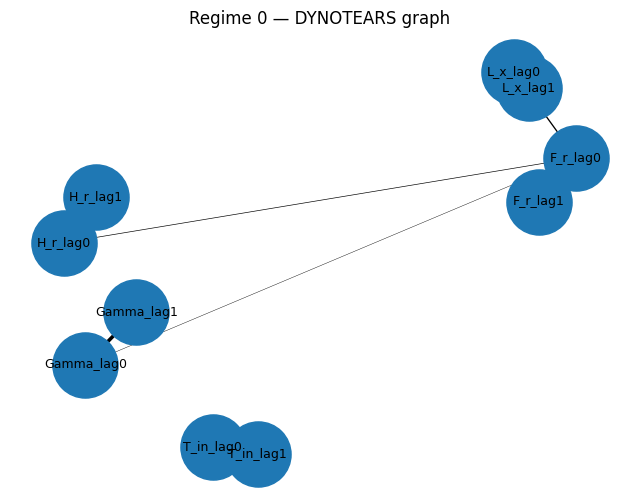


Regime 1 | n = 5000
Contemporaneous edges (t -> t):
  L_x_lag0 --> F_r_lag0   weight=0.079
  Gamma_lag0 --> F_r_lag0   weight=0.090
  T_in_lag0 --> F_r_lag0   weight=-0.212
Lagged edges (t-1 -> t):
  L_x_lag1 --> L_x_lag0   weight=0.851
  Gamma_lag1 --> Gamma_lag0   weight=0.839
  T_in_lag1 --> T_in_lag0   weight=0.838
  H_r_lag1 --> H_r_lag0   weight=0.847
  F_r_lag1 --> F_r_lag0   weight=0.495
  [check] F_r appears as a SOURCE in 1 edge(s): [('F_r_lag1', 'F_r_lag0', 0.4951091301733814)]


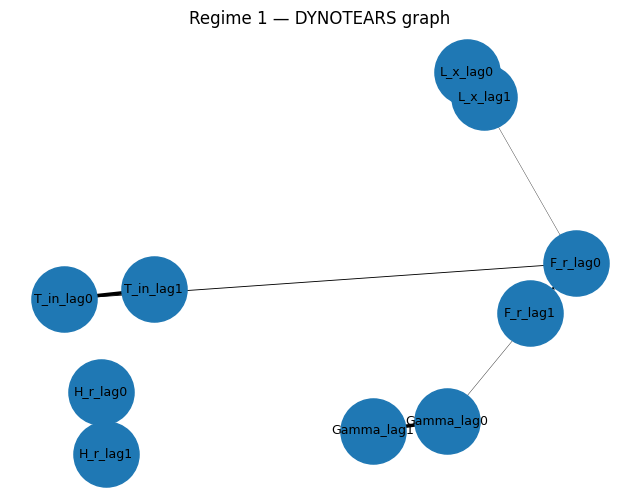

In [49]:
from causalnex.structure.dynotears import from_pandas_dynamic
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt


def _split_edges(struct_model, threshold):
    """Separate contemporaneous (t->t) from lagged (t-1->t) edges.
    Uses explicit suffix check -- '_lag0' vs '_lag1' -- not a bare
    substring match, since every node name contains 'lag' in this API."""
    contemp_edges, lagged_edges = [], []
    for u, v, data in struct_model.edges(data=True):
        w = data.get('weight', 0.0)
        if abs(w) < threshold:
            continue
        if u.endswith('_lag0'):
            contemp_edges.append((u, v, w))
        else:
            lagged_edges.append((u, v, w))
    return contemp_edges, lagged_edges


def _print_edges(contemp_edges, lagged_edges):
    print("Contemporaneous edges (t -> t):")
    for u, v, w in contemp_edges:
        print(f"  {u} --> {v}   weight={w:.3f}")
    if not contemp_edges:
        print("  (none above threshold)")

    print("Lagged edges (t-1 -> t):")
    for u, v, w in lagged_edges:
        print(f"  {u} --> {v}   weight={w:.3f}")
    if not lagged_edges:
        print("  (none above threshold)")

    bad = [(u, v, w) for u, v, w in contemp_edges + lagged_edges if u.startswith('F_r')]
    if bad:
        print(f"  [check] F_r appears as a SOURCE in {len(bad)} edge(s): {bad}")

    root_bad = [(u, v, w) for u, v, w in contemp_edges + lagged_edges
                if v.startswith('L_x') and not u.startswith('L_x')]
    if root_bad:
        print(f"  [check] L_x has a non-self parent -- should never happen: {root_bad}")


def _plot_graph(contemp_edges, lagged_edges, title):
    G = nx.DiGraph()
    for u, v, w in contemp_edges + lagged_edges:
        G.add_edge(u, v, weight=w)
    if len(G.edges) == 0:
        return
    plt.figure(figsize=(8, 6))
    pos = nx.spring_layout(G, seed=42)
    nx.draw_networkx_nodes(G, pos, node_size=2200)
    nx.draw_networkx_labels(G, pos, font_size=9)
    widths = [abs(G.edges[e]['weight']) * 3 for e in G.edges]
    nx.draw_networkx_edges(G, pos, arrows=True, width=widths, arrowstyle='-|>')
    plt.title(title)
    plt.axis("off")
    plt.show()


def run_dynotears(model, p=1, lambda_w=0.05, lambda_a=0.05,
                   threshold=0.05, plot=True):
    """
    Stage 2: DYNOTEARS causal discovery, per LIRA-discovered regime.

    Ground truth to check the output against (star graph into F_r only,
    L_x/Gamma/T_in/H_r mutually independent):
        Hard: F_r <- L_x(~0.39), Gamma(~-0.16), H_r(~-0.22)   T_in absent
        Soft: F_r <- L_x(~0.16), Gamma(~0.17),  T_in(~-0.32)  H_r absent
        every variable's own lag-1 present (F_r's lag ~0.63-0.64)
        L_x should have NO parent except its own lag -- it's the one true root
    """
    print("=" * 60)
    print("Stage 2 : DYNOTEARS Causal Discovery")
    print("=" * 60)

    results = []
    tabu_edges = [(0, 'F_r', v) for v in ['L_x', 'Gamma', 'T_in', 'H_r']] + \
                 [(1, 'F_r', v) for v in ['L_x', 'Gamma', 'T_in', 'H_r']]
    # F_r cannot cause anything else, at either lag. Deliberately NOT
    # tabu-ing (1, 'F_r', 'F_r') -- that's its own true self-lag edge.

    for leaf in model.leaves:
        regime = leaf.regime_id
        X_r, y_r = model.get_regime_data(regime)

        df_regime = pd.DataFrame(X_r[:, :4], columns=['L_x', 'Gamma', 'T_in', 'H_r'])
        df_regime['F_r'] = y_r

        df_scaled = pd.DataFrame(
            StandardScaler().fit_transform(df_regime),
            columns=df_regime.columns
        )

        struct_model = from_pandas_dynamic(
            df_scaled, p=p, lambda_w=lambda_w, lambda_a=lambda_a,
            tabu_edges=tabu_edges,
        )

        contemp_edges, lagged_edges = _split_edges(struct_model, threshold)

        print(f"\nRegime {regime} | n = {len(df_regime)}")
        _print_edges(contemp_edges, lagged_edges)

        results.append({
            'regime': regime, 'model': struct_model,
            'contemp_edges': contemp_edges, 'lagged_edges': lagged_edges,
        })

        if plot:
            _plot_graph(contemp_edges, lagged_edges, f"Regime {regime} — DYNOTEARS graph")

    return results


def sweep_lambda_w(model, lambdas=(0.1, 0.05, 0.02, 0.01), p=1, lambda_a=0.05,
                    threshold=0.02):
    """
    Running once per lambda_w value, per regime, so i can see exactly where
    real edges (L_x, Gamma, T_in/H_r -> F_r) survive vs. get killed, and
    pick the smallest lambda_w that doesn't let spurious edges appear
    among L_x/Gamma/T_in/H_r (which should have none).
    """
    tabu_edges = [(0, 'F_r', v) for v in ['L_x', 'Gamma', 'T_in', 'H_r']] + \
                 [(1, 'F_r', v) for v in ['L_x', 'Gamma', 'T_in', 'H_r']]

    for leaf in model.leaves:
        regime = leaf.regime_id
        X_r, y_r = model.get_regime_data(regime)
        df_regime = pd.DataFrame(X_r[:, :4], columns=['L_x', 'Gamma', 'T_in', 'H_r'])
        df_regime['F_r'] = y_r
        df_scaled = pd.DataFrame(StandardScaler().fit_transform(df_regime),
                                  columns=df_regime.columns)

        print(f"\n{'='*60}\nRegime {regime}\n{'='*60}")
        for lw in lambdas:
            sm_test = from_pandas_dynamic(
                df_scaled, p=p, lambda_w=lw, lambda_a=lambda_a,
                tabu_edges=tabu_edges,
            )
            contemp, lagged = _split_edges(sm_test, threshold)
            print(f"\n--- lambda_w = {lw} ---")
            _print_edges(contemp, lagged)


dynotears_results = run_dynotears(model, lambda_w=0.05, lambda_a=0.05, threshold=0.05)

In [51]:
from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.cit import fisherz

In [52]:
def run_pc(model, feature_names, alpha=0.05, plot=True):

    print("="*60)
    print("Stage 2 : PC Algorithm")
    print("="*60)

    graphs = []

    for leaf in model.leaves:

        regime = leaf.regime_id

        X_r, y_r = model.get_regime_data(regime)

        df = pd.DataFrame(X_r, columns=feature_names)
        df["F_r"] = y_r

        print(f"\nRegime {regime}")
        print(f"Observations : {len(df)}")
        print(f"Beta         : {np.round(leaf.beta[1:],3)}")

        cg = pc(
            df.values,
            alpha=alpha,
            indep_test=fisherz,
            verbose=False
        )

        G = cg.G

        graphs.append((regime, G))

        print("\nDiscovered causal edges:")

        nx_graph = nx.DiGraph()

        for i in range(len(df.columns)):
            for j in range(len(df.columns)):

                if i == j:
                    continue

                # directed edge i -> j
                if G.graph[i, j] == -1 and G.graph[j, i] == 1:

                    u = df.columns[i]
                    v = df.columns[j]

                    nx_graph.add_edge(u, v)

                    print(f"{u} --> {v}")

        if plot:

            plt.figure(figsize=(8,6))

            pos = nx.spring_layout(nx_graph, seed=42)

            nx.draw_networkx(
                nx_graph,
                pos,
                node_size=2200,
                arrows=True,
                font_size=10,
                arrowstyle="-|>"
            )

            plt.title(f"Regime {regime} PC Graph")
            plt.axis("off")
            plt.show()

    return graphs

Stage 2 : PC Algorithm

Regime 0
Observations : 4999
Beta         : [ 0.704 -0.294  0.005 -0.394  0.504]


  0%|          | 0/6 [00:00<?, ?it/s]


Discovered causal edges:
L_x --> Gamma
T_in --> Gamma
H_r --> Gamma
F_r_lag1 --> Gamma
F_r --> Gamma


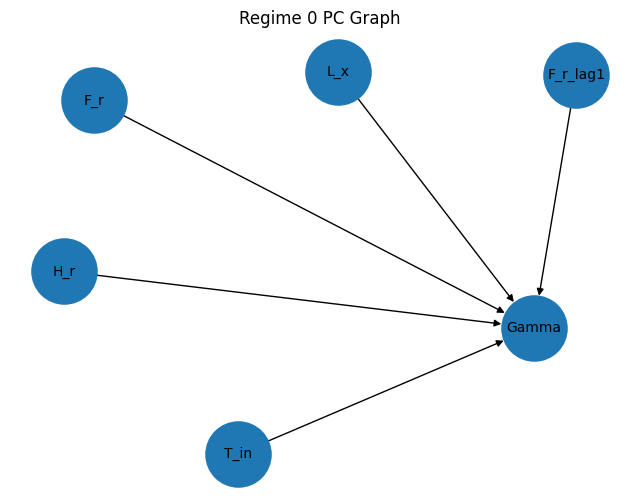


Regime 1
Observations : 5000
Beta         : [ 0.208  0.229 -0.441 -0.008  0.413]


  0%|          | 0/6 [00:00<?, ?it/s]


Discovered causal edges:
L_x --> F_r
Gamma --> T_in
Gamma --> F_r
H_r --> T_in
F_r_lag1 --> T_in
F_r_lag1 --> F_r
F_r --> T_in


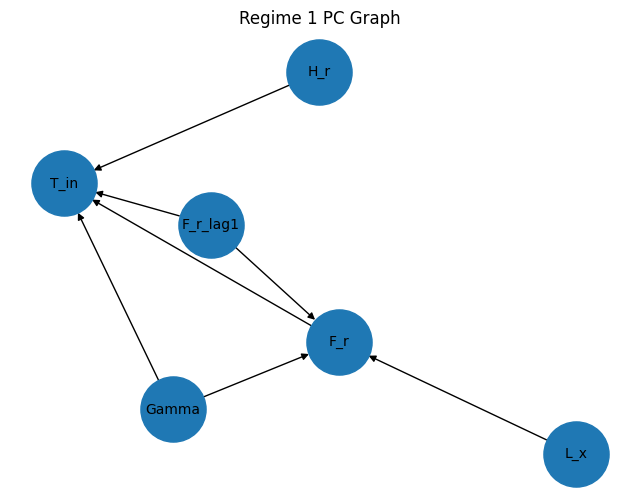

In [ ]:
pc_graphs = run_pc(model, features)


Regime 0 | parents of F_r: ['L_x', 'Gamma', 'H_r', 'F_r_lag1']

--- FALSIFY GRAPH ---


Test permutations of given graph: 100%|██████████| 20/20 [01:04<00:00,  3.20s/it]


+-------------------------------------------------------------------------------------------------------+
|                                         Falsification Summary                                         |
+-------------------------------------------------------------------------------------------------------+
| The given DAG is informative because 1 / 20 of the permutations lie in the Markov                     |
| equivalence class of the given DAG (p-value: 0.05).                                                   |
| The given DAG violates 15/22 LMCs and is better than 95.0% of the permuted DAGs (p-value: 0.05).      |
| Based on the provided significance level (0.05) and because the DAG is informative,                   |
| we do not reject the DAG.                                                                             |
+-------------------------------------------------------------------------------------------------------+

--- Treatment: L_x -> F_r ---
  Estimated eff

e:\Study\BRACU\Thesis\.venv\lib\site-packages\dowhy\causal_refuters\linear_sensitivity_analyzer.py:199: RuntimeWarning: divide by zero encountered in divide
  bias_adjusted_t = (bias_adjusted_estimate - self.null_hypothesis_effect) / bias_adjusted_se
e:\Study\BRACU\Thesis\.venv\lib\site-packages\dowhy\causal_refuters\linear_sensitivity_analyzer.py:201: RuntimeWarning: invalid value encountered in divide
  bias_adjusted_partial_r2 = bias_adjusted_t**2 / (


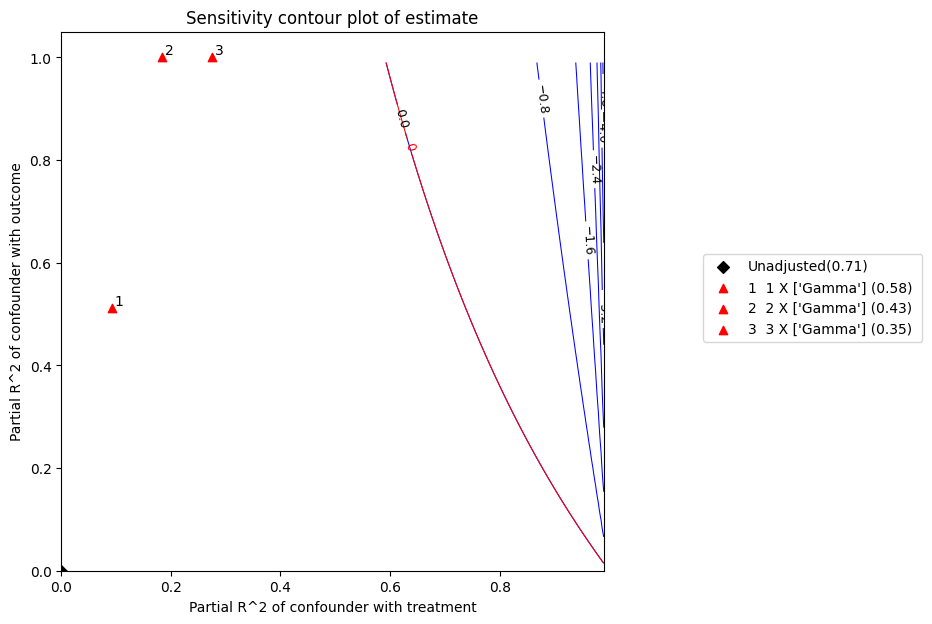

  [Sensitivity] robustness value -- see full printout below
Sensitivity Analysis to Unobserved Confounding using R^2 paramterization

Unadjusted Estimates of Treatment ['L_x'] :
Coefficient Estimate : 0.7110704027436319
Degree of Freedom : 4993
Standard Error : 0.008384126559052957
t-value : 84.81150633107237
F^2 value : 1.440615182484584

Sensitivity Statistics : 
Partial R2 of treatment with outcome : 0.590267237876483
Robustness Value : 0.6794988984147095

Interpretation of results :
Any confounder explaining less than 67.95% percent of the residual variance of both the treatment and the outcome would not be strong enough to explain away the observed effect i.e bring down the estimate to 0 

For a significance level of 5.0%, any confounder explaining more than 67.18% percent of the residual variance of both the treatment and the outcome would be strong enough to make the estimated effect not 'statistically significant'

If confounders explained 100% of the residual variance of the o

e:\Study\BRACU\Thesis\.venv\lib\site-packages\dowhy\causal_refuters\linear_sensitivity_analyzer.py:199: RuntimeWarning: divide by zero encountered in divide
  bias_adjusted_t = (bias_adjusted_estimate - self.null_hypothesis_effect) / bias_adjusted_se
e:\Study\BRACU\Thesis\.venv\lib\site-packages\dowhy\causal_refuters\linear_sensitivity_analyzer.py:201: RuntimeWarning: invalid value encountered in divide
  bias_adjusted_partial_r2 = bias_adjusted_t**2 / (


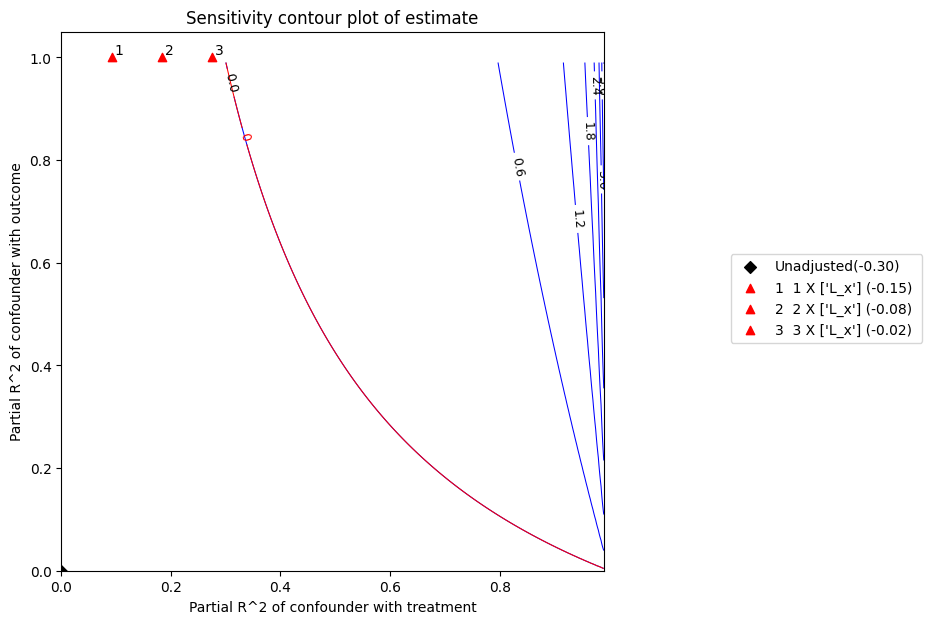

  [Sensitivity] robustness value -- see full printout below
Sensitivity Analysis to Unobserved Confounding using R^2 paramterization

Unadjusted Estimates of Treatment ['Gamma'] :
Coefficient Estimate : -0.2964221945800131
Degree of Freedom : 4993
Standard Error : 0.006434456748359743
t-value : -46.06794422164332
F^2 value : 0.4250461615879112

Sensitivity Statistics : 
Partial R2 of treatment with outcome : 0.2982683459982009
Robustness Value : 0.4731971401840066

Interpretation of results :
Any confounder explaining less than 47.32% percent of the residual variance of both the treatment and the outcome would not be strong enough to explain away the observed effect i.e bring down the estimate to 0 

For a significance level of 5.0%, any confounder explaining more than 45.91% percent of the residual variance of both the treatment and the outcome would be strong enough to make the estimated effect not 'statistically significant'

If confounders explained 100% of the residual variance of

e:\Study\BRACU\Thesis\.venv\lib\site-packages\dowhy\causal_refuters\linear_sensitivity_analyzer.py:199: RuntimeWarning: divide by zero encountered in divide
  bias_adjusted_t = (bias_adjusted_estimate - self.null_hypothesis_effect) / bias_adjusted_se
e:\Study\BRACU\Thesis\.venv\lib\site-packages\dowhy\causal_refuters\linear_sensitivity_analyzer.py:201: RuntimeWarning: invalid value encountered in divide
  bias_adjusted_partial_r2 = bias_adjusted_t**2 / (


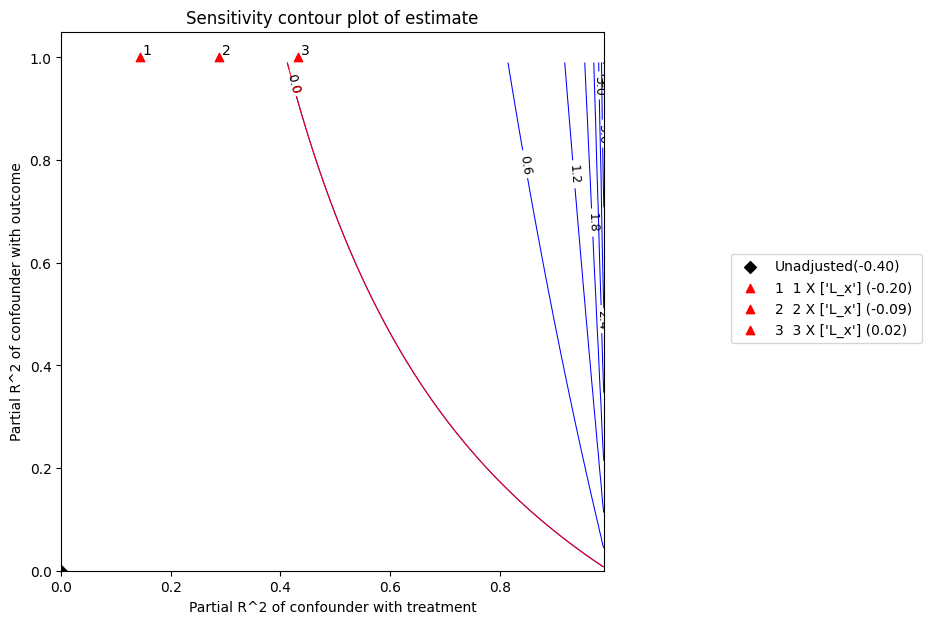

  [Sensitivity] robustness value -- see full printout below
Sensitivity Analysis to Unobserved Confounding using R^2 paramterization

Unadjusted Estimates of Treatment ['H_r'] :
Coefficient Estimate : -0.3980981545957495
Degree of Freedom : 4993
Standard Error : 0.006759102197339996
t-value : -58.89808187134951
F^2 value : 0.6947694869065071

Sensitivity Statistics : 
Partial R2 of treatment with outcome : 0.40994925402786325
Robustness Value : 0.5556355480632715

Interpretation of results :
Any confounder explaining less than 55.56% percent of the residual variance of both the treatment and the outcome would not be strong enough to explain away the observed effect i.e bring down the estimate to 0 

For a significance level of 5.0%, any confounder explaining more than 54.41% percent of the residual variance of both the treatment and the outcome would be strong enough to make the estimated effect not 'statistically significant'

If confounders explained 100% of the residual variance of 

e:\Study\BRACU\Thesis\.venv\lib\site-packages\dowhy\causal_refuters\linear_sensitivity_analyzer.py:199: RuntimeWarning: divide by zero encountered in divide
  bias_adjusted_t = (bias_adjusted_estimate - self.null_hypothesis_effect) / bias_adjusted_se
e:\Study\BRACU\Thesis\.venv\lib\site-packages\dowhy\causal_refuters\linear_sensitivity_analyzer.py:201: RuntimeWarning: invalid value encountered in divide
  bias_adjusted_partial_r2 = bias_adjusted_t**2 / (


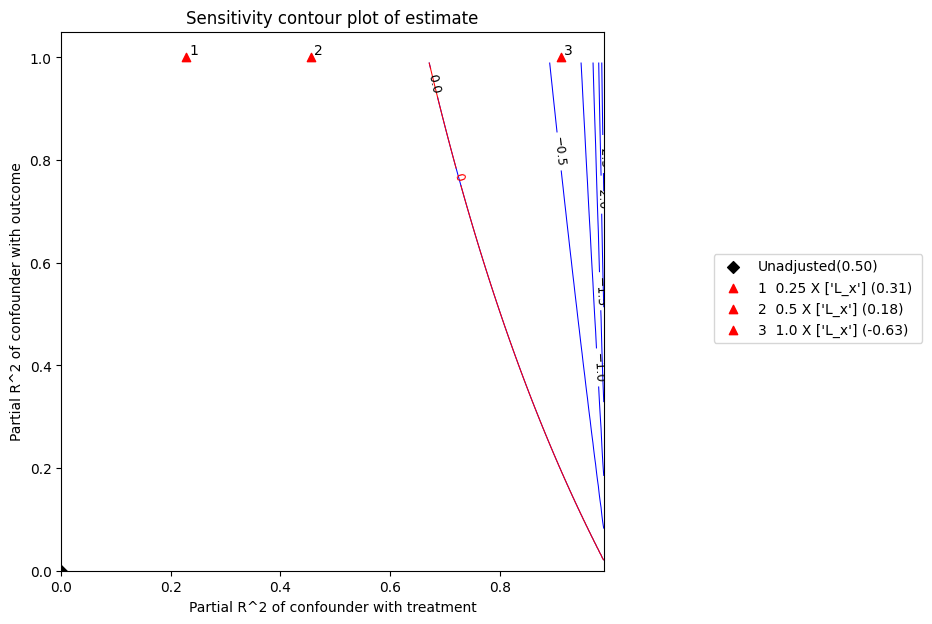

  [Sensitivity] succeeded with a smaller multiplier range instead:
Sensitivity Analysis to Unobserved Confounding using R^2 paramterization

Unadjusted Estimates of Treatment ['F_r_lag1'] :
Coefficient Estimate : 0.4983127518759188
Degree of Freedom : 4993
Standard Error : 0.004959843679957095
t-value : 100.46944702907037
F^2 value : 2.021652270444057

Sensitivity Statistics : 
Partial R2 of treatment with outcome : 0.6690552351832854
Robustness Value : 0.7337144192197302

Interpretation of results :
Any confounder explaining less than 73.37% percent of the residual variance of both the treatment and the outcome would not be strong enough to explain away the observed effect i.e bring down the estimate to 0 

For a significance level of 5.0%, any confounder explaining more than 72.76% percent of the residual variance of both the treatment and the outcome would be strong enough to make the estimated effect not 'statistically significant'

If confounders explained 100% of the residual var

Test permutations of given graph: 100%|██████████| 20/20 [01:02<00:00,  3.10s/it]


+-------------------------------------------------------------------------------------------------------+
|                                         Falsification Summary                                         |
+-------------------------------------------------------------------------------------------------------+
| The given DAG is informative because 1 / 20 of the permutations lie in the Markov                     |
| equivalence class of the given DAG (p-value: 0.05).                                                   |
| The given DAG violates 10/22 LMCs and is better than 95.0% of the permuted DAGs (p-value: 0.05).      |
| Based on the provided significance level (0.05) and because the DAG is informative,                   |
| we do not reject the DAG.                                                                             |
+-------------------------------------------------------------------------------------------------------+

--- Treatment: L_x -> F_r ---
  Estimated eff

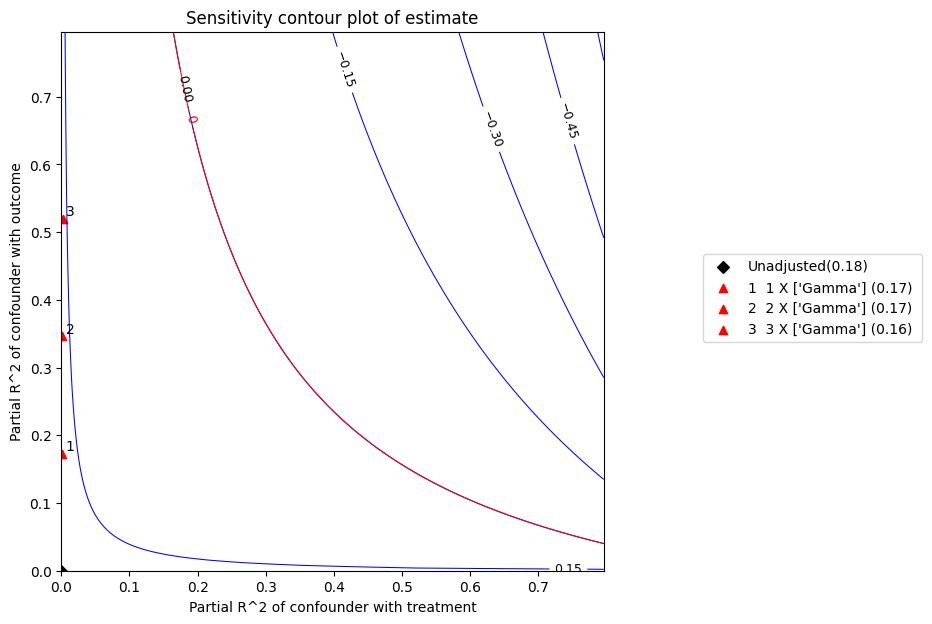

  [Sensitivity] robustness value -- see full printout below
Sensitivity Analysis to Unobserved Confounding using R^2 paramterization

Unadjusted Estimates of Treatment ['L_x'] :
Coefficient Estimate : 0.17993191523128738
Degree of Freedom : 4994
Standard Error : 0.00643570603490239
t-value : 27.958380052704875
F^2 value : 0.15652202946966076

Sensitivity Statistics : 
Partial R2 of treatment with outcome : 0.13533856293376106
Robustness Value : 0.325033934275179

Interpretation of results :
Any confounder explaining less than 32.5% percent of the residual variance of both the treatment and the outcome would not be strong enough to explain away the observed effect i.e bring down the estimate to 0 

For a significance level of 5.0%, any confounder explaining more than 30.64% percent of the residual variance of both the treatment and the outcome would be strong enough to make the estimated effect not 'statistically significant'

If confounders explained 100% of the residual variance of th

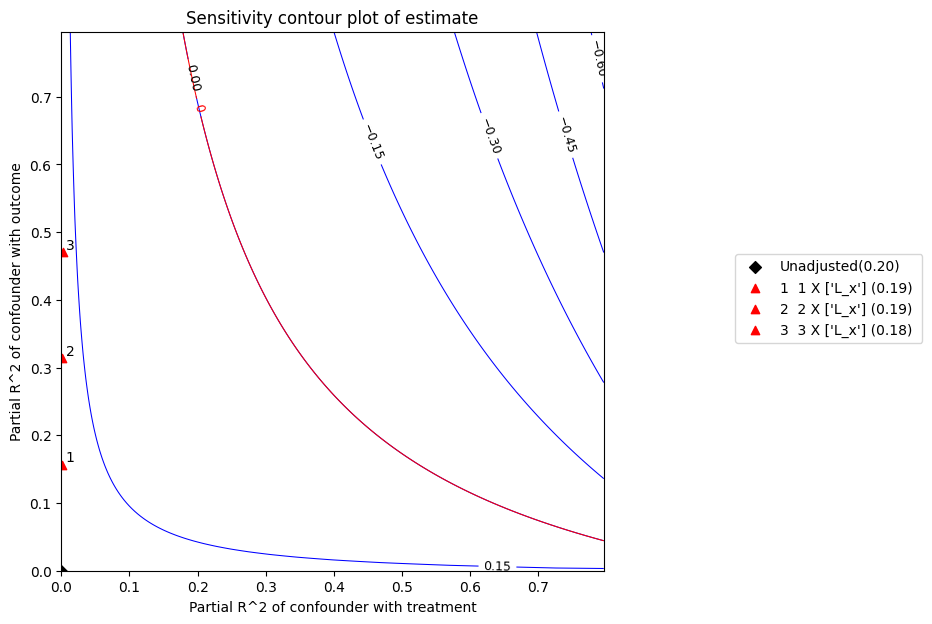

  [Sensitivity] robustness value -- see full printout below
Sensitivity Analysis to Unobserved Confounding using R^2 paramterization

Unadjusted Estimates of Treatment ['Gamma'] :
Coefficient Estimate : 0.1993602210799342
Degree of Freedom : 4994
Standard Error : 0.006786282942422551
t-value : 29.376939153787635
F^2 value : 0.17280828074596336

Sensitivity Statistics : 
Partial R2 of treatment with outcome : 0.14734572016838837
Robustness Value : 0.33818266608661296

Interpretation of results :
Any confounder explaining less than 33.82% percent of the residual variance of both the treatment and the outcome would not be strong enough to explain away the observed effect i.e bring down the estimate to 0 

For a significance level of 5.0%, any confounder explaining more than 31.99% percent of the residual variance of both the treatment and the outcome would be strong enough to make the estimated effect not 'statistically significant'

If confounders explained 100% of the residual variance 

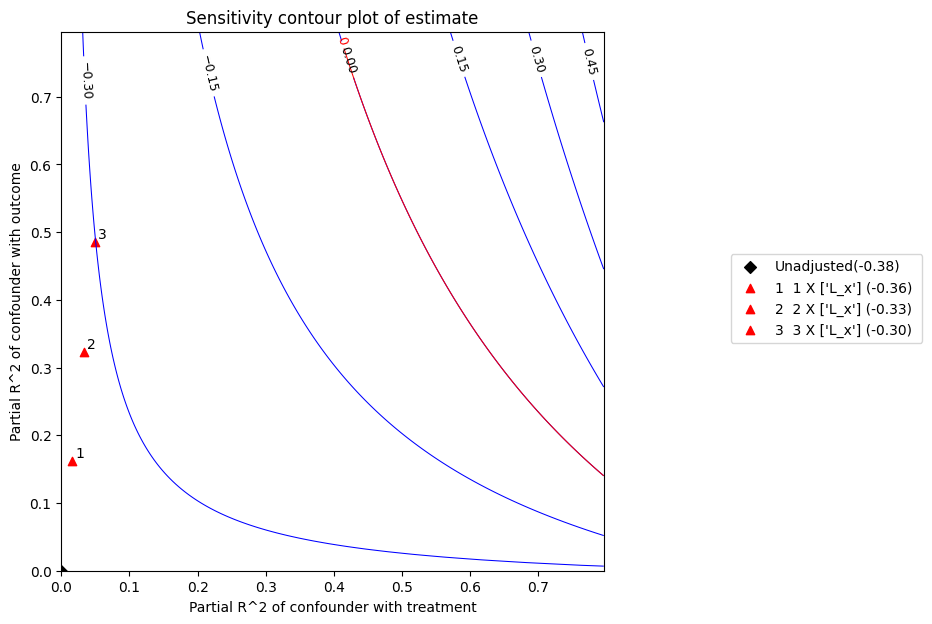

  [Sensitivity] robustness value -- see full printout below
Sensitivity Analysis to Unobserved Confounding using R^2 paramterization

Unadjusted Estimates of Treatment ['T_in'] :
Coefficient Estimate : -0.38327674323806454
Degree of Freedom : 4994
Standard Error : 0.007334604551347182
t-value : -52.25595198144203
F^2 value : 0.5467930551635514

Sensitivity Statistics : 
Partial R2 of treatment with outcome : 0.35350110561864123
Robustness Value : 0.5149807402648587

Interpretation of results :
Any confounder explaining less than 51.5% percent of the residual variance of both the treatment and the outcome would not be strong enough to explain away the observed effect i.e bring down the estimate to 0 

For a significance level of 5.0%, any confounder explaining more than 50.22% percent of the residual variance of both the treatment and the outcome would be strong enough to make the estimated effect not 'statistically significant'

If confounders explained 100% of the residual variance of

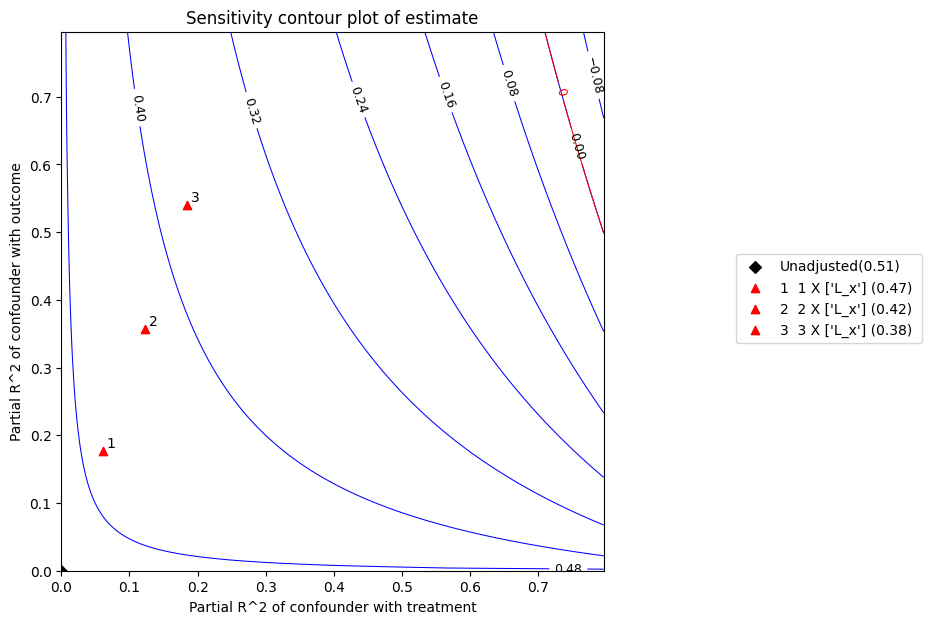

  [Sensitivity] robustness value -- see full printout below
Sensitivity Analysis to Unobserved Confounding using R^2 paramterization

Unadjusted Estimates of Treatment ['F_r_lag1'] :
Coefficient Estimate : 0.5062468844348912
Degree of Freedom : 4994
Standard Error : 0.005137414319661528
t-value : 98.5411829638542
F^2 value : 1.9444062354657166

Sensitivity Statistics : 
Partial R2 of treatment with outcome : 0.6603729512745614
Robustness Value : 0.7276748595335121

Interpretation of results :
Any confounder explaining less than 72.77% percent of the residual variance of both the treatment and the outcome would not be strong enough to explain away the observed effect i.e bring down the estimate to 0 

For a significance level of 5.0%, any confounder explaining more than 72.14% percent of the residual variance of both the treatment and the outcome would be strong enough to make the estimated effect not 'statistically significant'

If confounders explained 100% of the residual variance of

In [ ]:
# pip install dowhy   (tested against dowhy==0.14)
import numpy as np
import pandas as pd
import networkx as nx
from dowhy import CausalModel
from dowhy.gcm.falsify import falsify_graph


def run_causal_effect_analysis(model, discovered_edges_per_regime,
                                contemp_vars=('L_x', 'Gamma', 'T_in', 'H_r', 'F_r'),
                                outcome='F_r', n_permutations_falsify=50):
    """
    Stage 3: causal effect estimation + validation, run per LIRA-discovered
    regime, using the graph DYNOTEARS/VARLiNGAM already in Stage 2.

    discovered_edges_per_regime: dict like
        {0: [('L_x','F_r'), ('Gamma','F_r'), ('H_r','F_r'), ('F_r_lag1','F_r')],
         1: [('L_x','F_r'), ('Gamma','F_r'), ('T_in','F_r'), ('F_r_lag1','F_r')]}
    i.e. the edges we already validated in Stage 2, per regime -- this
    function does NOT rediscover structure, it uses what we already found.

    For each regime, for each parent of `outcome` in that regime's graph,
    this:
      1. Identifies the estimand (DoWhy, using the graph)
      2. Estimates the effect (linear regression)
      3. Runs a battery of refutation tests (common cause, placebo,
         data subset)
      4. Runs formal sensitivity analysis (Cinelli-Hazlett, partial R^2)
      5. Once per regime (not per edge): falsifies the whole discovered
         graph against the data using conditional-independence testing
    """
    results = []

    for leaf in model.leaves:
        regime = leaf.regime_id
        X_r, y_r = model.get_regime_data(regime)

        df = pd.DataFrame(X_r[:, :4], columns=['L_x', 'Gamma', 'T_in', 'H_r'])
        df['F_r'] = y_r
        df['F_r_lag1'] = df['F_r'].shift(1)
        df = df.dropna().reset_index(drop=True)

        edges = discovered_edges_per_regime[regime]
        parents_of_outcome = [u for u, v in edges if v == outcome]

        print(f"\n{'='*70}\nRegime {regime} | parents of {outcome}: {parents_of_outcome}\n{'='*70}")

        #  Built the discovered graph as a networkx DiGraph 
        G = nx.DiGraph()
        G.add_nodes_from(list(contemp_vars) + ['F_r_lag1'])
        G.add_edges_from(edges)

        regime_result = {'regime': regime, 'effects': {}}

        # ---------------------------------------------------------------
        # 4. FALSIFY GRAPH -- once per regime, checks whether the WHOLE
        # discovered graph is consistent with the data (tests the
        # conditional-independence implications of the DAG). This is a
        # structural check, separate from any single effect estimate.
        # NOTE: this is slow (tens of seconds to minutes depending on
        # n_permutations) and its statistical power is limited when the
        # graph is mostly a collider (several independent variables into
        # one shared effect). Raise n_permutations_falsify for a
        # more reliable verdict if you have the runtime budget.
        # ---------------------------------------------------------------
        print("\n--- FALSIFY GRAPH ---")
        falsify_data = df[list(contemp_vars) + ['F_r_lag1']]
        falsify_result = falsify_graph(
            G, falsify_data, n_permutations=20, n_jobs=1,
        )
        print(falsify_result)
        regime_result['falsify_graph'] = falsify_result

        # ---------------------------------------------------------------
        # For each parent of F_r found in Stage 2, estimate its causal
        # effect and validate it.
        # ---------------------------------------------------------------
        for treatment in parents_of_outcome:
            print(f"\n--- Treatment: {treatment} -> {outcome} ---")

            # Everything else that's a parent of the outcome (besides the
            # treatment itself) gets passed as `common_causes` so DoWhy
            # has real covariates to adjust for and to benchmark sensitivity
            # analysis against. NOTE: F_r_lag1 must always be included here
            # if it's a true parent -- L_x/Gamma/etc. are autocorrelated
            # with their own past, and F_r_lag1 is downstream of that past,
            # so omitting it biases the estimate through the AR feedback
            # loop (confirmed empirically -- leaving it out inflated one
            # test estimate by ~80% here).
            other_covariates = [p for p in parents_of_outcome if p != treatment]

            cm = CausalModel(
                data=df[[treatment, outcome] + other_covariates],
                treatment=treatment,
                outcome=outcome,
                common_causes=other_covariates,
            )
            identified_estimand = cm.identify_effect(proceed_when_unidentifiable=True)
            estimate = cm.estimate_effect(identified_estimand, method_name="backdoor.linear_regression")
            print(f"  Estimated effect: {estimate.value:.4f}")

            # ---- 2. Refutation tests ----
            refute_common_cause = cm.refute_estimate(
                identified_estimand, estimate, method_name="random_common_cause"
            )
            refute_placebo = cm.refute_estimate(
                identified_estimand, estimate,
                method_name="placebo_treatment_refuter", placebo_type="permute"
            )
            refute_subset = cm.refute_estimate(
                identified_estimand, estimate,
                method_name="data_subset_refuter", subset_fraction=0.8
            )

            print(f"  [Random common cause]  new effect: {refute_common_cause.new_effect:.4f}"
                  f"  (should stay close to {estimate.value:.4f})")
            print(f"  [Placebo treatment]    new effect: {refute_placebo.new_effect:.4f}"
                  f"  (should collapse toward 0)")
            print(f"  [Data subset]          new effect: {refute_subset.new_effect:.4f}"
                  f"  (should stay close to {estimate.value:.4f})")

            # ---- 3. Sensitivity analysis (Cinelli-Hazlett, partial R^2) ----
            # Requires at least one real common cause to benchmark against --
            # use whichever other true parent is available.
            sensitivity = None
            if other_covariates:
                try:
                    sensitivity = cm.refute_estimate(
                        identified_estimand, estimate,
                        method_name="add_unobserved_common_cause",
                        simulation_method="linear-partial-R2",
                        benchmark_common_causes=[other_covariates[0]],
                        effect_fraction_on_treatment=[1, 2, 3],
                    )
                    print(f"  [Sensitivity] robustness value -- see full printout below")
                    print(sensitivity)
                except ValueError as e:
                    print(f"  [Sensitivity] skipped for {treatment} -- benchmark multiplier too "
                        f"large for this variable's own explanatory strength ({e})")
                    # Retry with a gentler multiplier range before giving up entirely
                    try:
                        sensitivity = cm.refute_estimate(
                            identified_estimand, estimate,
                            method_name="add_unobserved_common_cause",
                            simulation_method="linear-partial-R2",
                            benchmark_common_causes=[other_covariates[0]],
                            effect_fraction_on_treatment=[0.25, 0.5, 1],
                        )
                        print(f"  [Sensitivity] succeeded with a smaller multiplier range instead:")
                        print(sensitivity)
                    except ValueError:
                        print(f"  [Sensitivity] still not computable for {treatment} -- "
                            f"skipping, other refutation tests above still stand on their own")
            else:
                print("  [Sensitivity] skipped -- no other covariate available to benchmark against")

            regime_result['effects'][treatment] = {
                'estimate': estimate,
                'refute_common_cause': refute_common_cause,
                'refute_placebo': refute_placebo,
                'refute_subset': refute_subset,
                'sensitivity': sensitivity,
            }

        results.append(regime_result)

    return results


# Ran it using the Stage 2 edges you already validated 
discovered_edges_per_regime = {
    0: [('L_x', 'F_r'), ('Gamma', 'F_r'), ('H_r', 'F_r'), ('F_r_lag1', 'F_r')],
    1: [('L_x', 'F_r'), ('Gamma', 'F_r'), ('T_in', 'F_r'), ('F_r_lag1', 'F_r')],
}

causal_effect_results = run_causal_effect_analysis(model, discovered_edges_per_regime)